In [1]:
import pylbsr.notebooks
import pylbsr.misc

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
from dotmap import DotMap
from tqdm import tqdm

import parnet
from parnet_additional_utils import GzListDataset, ParnetModelName, load_parnet_model
from parnet.layers import LinearProjectionHead

/home/lhofer/pixi-envs/parnet--globalclip-head-6013472398032450694/envs/parnet-dev-cu12/lib/python3.10/site-packages/gin/config.py:615: FutureWarning: `NLLLoss2d` has been deprecated. Please use `NLLLoss` instead as a drop-in replacement and see https://pytorch.org/docs/main/nn.html#torch.nn.NLLLoss for more details.
  decorated_class = decorating_meta(cls.__name__, (cls,), overrides)
Seed set to 42


In [2]:
_notebook_name = "03_integrated_gradients.ipynb"
_notebook_path = f"notebooks/globalclip-head/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)
logger = pylbsr.misc.init_logger(_notebook_name)
PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

[08:11:06] INFO - Project directory: /mnt/storage1/workspace/lhofer/parnet--globalclip-head


In [39]:
# ── GPU setup ──────────────────────────────────────────────────────────────────
pylbsr.misc.set_seed(42)

params_gpu_index = 0
device = torch.device(f"cuda:{params_gpu_index}")
torch.cuda.set_device(params_gpu_index)

if torch.cuda.is_available():
    logger.info(f"Using GPU: {torch.cuda.get_device_name(device)}")
else:
    logger.warning("No GPU available, using CPU instead.")

[15:24:05] INFO - Using GPU: NVIDIA RTX A4000


Seed set to 42
⏱ 0.00 s (00:00:00)


In [40]:
# ── Parameters ─────────────────────────────────────────────────────────────────
# Run to load the model from
EVAL_RUN = "parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50"

# Pretrained backbone this run was fine-tuned from
PRETRAINED_MODEL = ParnetModelName.PARNET_7M_0_0   # or PARNET_21M_0_0 / PARNET_21M_NONE

# Data used for this run (filtered or raw)
USE_FILTERED_DATA = True

# Integrated Gradients settings
params_n_steps: int = 50
params_n_sequences: int = None

# Data
params_seq_length: int = 600
params_num_tasks: int = 1

⏱ 0.00 s (00:00:00)


In [41]:
# ── Filepaths ──────────────────────────────────────────────────────────────────
_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.yaml").read_text())

_data_key = "data_lysate_noNHS_filtered" if USE_FILTERED_DATA else "data_lysate_noNHS"

FILEPATHS = DotMap()
FILEPATHS["data"] = Path(_fp_cfg["global_clip"][_data_key])
FILEPATHS["pretrained_model"] = Path(_fp_cfg["models"][PRETRAINED_MODEL.value])
FILEPATHS["run_dir"] = PROJECT_DIR / "results" / "globalclip-head" / "training" / EVAL_RUN
FILEPATHS["output_dir"] = FILEPATHS["run_dir"] / "integrated_gradients"
FILEPATHS["figures_dir"] = PROJECT_DIR / "results" / "globalclip-head" / "figures"

FILEPATHS["output_dir"].mkdir(parents=True, exist_ok=True)
FILEPATHS["figures_dir"].mkdir(parents=True, exist_ok=True)

logger.info(f"Run dir:    {FILEPATHS.run_dir}")
logger.info(f"Output dir: {FILEPATHS.output_dir}")

[15:24:07] INFO - Run dir:    /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50
[15:24:07] INFO - Output dir: /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients


⏱ 0.01 s (00:00:00)


In [42]:
# ── Load test dataset ──────────────────────────────────────────────────────────
test_ds = GzListDataset(
    FILEPATHS.data, split="test",
    length=params_seq_length, total_key="globalCLIP", control_key="control",
    shuffle=False, mmap=True,
)

n_sequences = len(test_ds) if params_n_sequences is None else params_n_sequences
logger.info(f"Test size: {len(test_ds)} — computing IG on {n_sequences} sequences")

Loading (mmap) globalclip_lysate_noNHS.minreads3.maxsignal1000.pt split='test'... 

[15:24:19] INFO - Test size: 4896 — computing IG on 4896 sequences


loaded 4896 samples.
⏱ 9.90 s (00:00:09)


In [43]:
# ── Load model ─────────────────────────────────────────────────────────────────
class GlobalCLIPHead(torch.nn.Module):
    def __init__(self, num_tasks=1):
        super().__init__()
        self.projection = LinearProjectionHead(num_tasks)

    def forward(self, inputs, **kwargs):
        logit = self.projection(inputs)
        logprob = logit - torch.logsumexp(logit, dim=-1, keepdim=True)
        return {
            'total': logprob,
            'mix_coeff': torch.ones(inputs.shape[0], 1, device=inputs.device),
        }

model = load_parnet_model(
    PRETRAINED_MODEL,
    FILEPATHS["pretrained_model"],
    dtype=torch.float32,
    device=device,
)

model.head = GlobalCLIPHead(num_tasks=params_num_tasks).to(device)

# initialize lazy parameters — derive hidden dim from the backbone (512 for 7M, 768 for 21M)
with torch.no_grad():
    _probe_seq = test_ds[0]["inputs"]["sequence"].unsqueeze(0).to(device)
    _backbone_out = model.body(model.stem(_probe_seq))
    _hidden_dim = _backbone_out.shape[1]
    model.head(_backbone_out)
logger.info(f"Backbone hidden dim: {_hidden_dim}")

# load fine-tuned weights
_checkpoint = torch.load(FILEPATHS["run_dir"] / "model.statedict.pt", map_location=device)
model.load_state_dict(_checkpoint["state_dict"])
model.eval()
logger.info(f"Model loaded from: {FILEPATHS.run_dir / 'model.statedict.pt'}")

[15:24:39] INFO - Backbone hidden dim: 512
[15:24:39] INFO - Model loaded from: /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/model.statedict.pt


⏱ 0.66 s (00:00:00)


In [44]:
# ── Integrated Gradients implementation ────────────────────────────────────────
def integrated_gradients(model, sequence, n_steps=50):
    """
    Compute Integrated Gradients for a single sequence.
    
    Args:
        model: fine-tuned GlobalCLIP model
        sequence: (1, 4, 600) one-hot encoded sequence tensor
        n_steps: number of interpolation steps between baseline and input
    
    Returns:
        attributions: (4, 600) attribution scores
    """
    baseline = torch.zeros_like(sequence)  # all-zeros baseline (no information)
    
    # interpolate between baseline and input: (n_steps, 1, 4, 600)
    alphas = torch.linspace(0, 1, n_steps, device=sequence.device)
    interpolated = torch.stack([
        baseline + alpha * (sequence - baseline)
        for alpha in alphas
    ])  # (n_steps, 1, 4, 600)
    interpolated = interpolated.squeeze(1)  # (n_steps, 4, 600)
    interpolated.requires_grad_(True)
    
    # forward pass on all interpolated sequences at once
    output = model(sequence=interpolated)
    target = output['total'].sum()  # scalar
    
    # compute gradients
    target.backward()
    grads = interpolated.grad  # (n_steps, 4, 600)
    
    # average gradients and scale by (input - baseline)
    avg_grads = grads.mean(0)  # (4, 600)
    attributions = avg_grads * (sequence.squeeze(0) - baseline.squeeze(0))
    
    return attributions.detach().cpu()

⏱ 0.00 s (00:00:00)


In [45]:
# ── Compute IG for all test sequences ──────────────────────────────────────────
all_attributions = []
all_sequences = []

model.eval()
for i in tqdm(range(n_sequences)):
    sample = test_ds[i]
    
    # get one-hot encoded sequence (4, 600)
    sequence = sample["inputs"]["sequence"].unsqueeze(0).to(device)  # (1, 4, 600)
    
    # compute IG
    attrs = integrated_gradients(model, sequence, n_steps=params_n_steps)  # (4, 600)
    
    all_attributions.append(attrs.numpy())
    all_sequences.append(sample["inputs"]["sequence"].numpy())

all_attributions = np.stack(all_attributions)  # (n_sequences, 4, 600)
all_sequences = np.stack(all_sequences)         # (n_sequences, 4, 600)

logger.info(f"Computed IG for {n_sequences} sequences")
logger.info(f"Attribution maps shape: {all_attributions.shape}")

100%|██████████| 4896/4896 [08:30<00:00,  9.59it/s]
[15:33:32] INFO - Computed IG for 4896 sequences
[15:33:32] INFO - Attribution maps shape: (4896, 4, 600)


⏱ 510.50 s (00:08:30)


In [46]:
# ── Save attribution maps ──────────────────────────────────────────────────────
np.save(FILEPATHS["output_dir"] / "attributions.npy", all_attributions)
np.save(FILEPATHS["output_dir"] / "sequences.npy", all_sequences)
logger.info(f"Saved attribution maps → {FILEPATHS.output_dir}")

[15:49:13] INFO - Saved attribution maps → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients


⏱ 0.93 s (00:00:00)


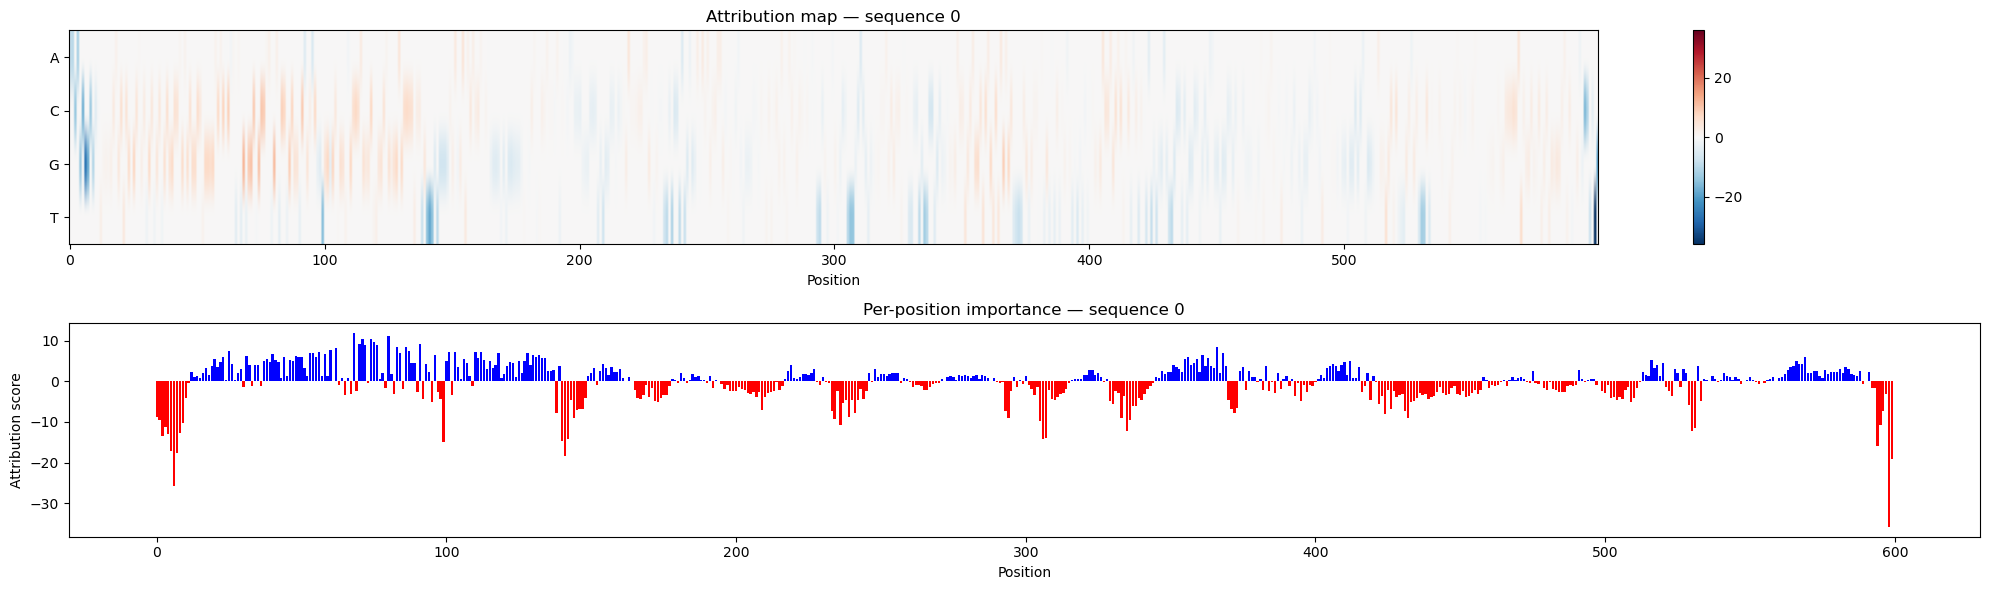

⏱ 1.20 s (00:00:01)


In [47]:
# ── Visualize single attribution map ───────────────────────────────────────────
NUCLEOTIDES = ["A", "C", "G", "T"]
SEQ_IDX = 0  # which sequence to visualize

fig, axes = plt.subplots(2, 1, figsize=(20, 6))

# ── Attribution map (4 nucleotides x 600 positions) ───────────────────────────
im = axes[0].imshow(
    all_attributions[SEQ_IDX],
    aspect="auto",
    cmap="RdBu_r",
    vmin=-np.abs(all_attributions[SEQ_IDX]).max(),
    vmax=np.abs(all_attributions[SEQ_IDX]).max(),
)
axes[0].set_yticks(range(4))
axes[0].set_yticklabels(NUCLEOTIDES)
axes[0].set_xlabel("Position")
axes[0].set_title(f"Attribution map — sequence {SEQ_IDX}")
plt.colorbar(im, ax=axes[0])

# ── Per-position importance (sum over nucleotides) ─────────────────────────────
importance = all_attributions[SEQ_IDX].sum(axis=0)  # (600,)
axes[1].bar(range(600), importance, color=["red" if v < 0 else "blue" for v in importance])
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Attribution score")
axes[1].set_title(f"Per-position importance — sequence {SEQ_IDX}")

plt.tight_layout()
plt.savefig(FILEPATHS["figures_dir"] / f"attribution_map_seq{SEQ_IDX}.png", dpi=150, bbox_inches="tight")
plt.show()

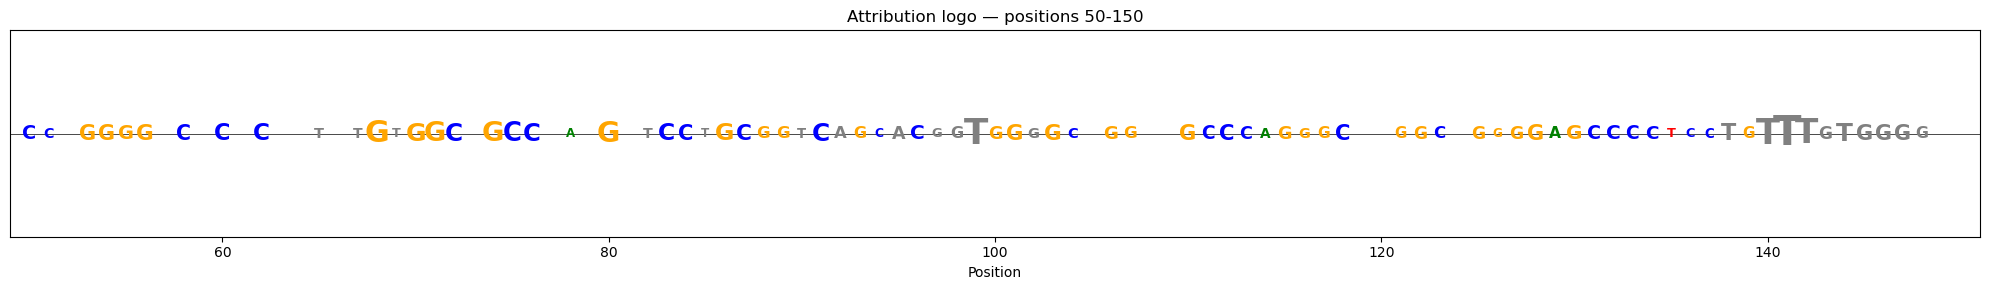

<Figure size 640x480 with 0 Axes>

⏱ 0.15 s (00:00:00)


In [48]:
def plot_attribution_logo(attributions, sequence, start=0, end=100, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 3))
    
    NUCLEOTIDES = ["A", "C", "G", "T"]
    COLORS = {"A": "green", "C": "blue", "G": "orange", "T": "red"}
    
    # normalize scores to make font sizes more visible
    max_score = np.abs(attributions[:, start:end]).max()
    
    for pos in range(start, end):
        for nuc_idx, nuc in enumerate(NUCLEOTIDES):
            if sequence[nuc_idx, pos] == 0:
                continue
            score = attributions[nuc_idx, pos]
            if abs(score) < 0.1 * max_score:  # skip bottom 10%
                continue
            fontsize = 6 + (abs(score) / max_score) * 24  # scale 6-30
            color = COLORS[nuc] if score > 0 else "gray"
            ax.text(
                pos, 0, nuc,
                fontsize=fontsize,
                color=color,
                ha="center", va="center",
                fontweight="bold",
            )
    
    ax.set_xlim(start - 1, end + 1)
    ax.set_ylim(-1, 1)
    ax.set_xlabel("Position")
    ax.set_title(f"Attribution logo — positions {start}-{end}")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_yticks([])
    return ax

fig, ax = plt.subplots(figsize=(20, 3))
plot_attribution_logo(all_attributions[SEQ_IDX], all_sequences[SEQ_IDX], start=50, end=150, ax=ax)
plt.tight_layout()
plt.show()
plt.savefig(FILEPATHS["figures_dir"] / f"attribution_logo_seq{SEQ_IDX}.png", dpi=150, bbox_inches="tight")
plt.show()

In [49]:
# ── Load RBP motifs ────────────────────────────────────────────────────────────
import pylbsr.bio.motifs as motifs_lib
from pylbsr.bio.motifs.motif import convert_matrix_type

MOTIFS_DIR = Path("/mnt/storage1/ml4rg26-shared/rbp_binding_motifs")
DATABASES = ["mCrossBase", "ATtRACT", "RBPmap_1.2", "oRNAment", "RBPDB"]

def load_motif_ppm(f):
    """Load a .transfac motif and convert to PPM for scoring."""
    with open(f) as fh:
        ms = motifs_lib.read_motifs_transfac(fh)
    if not ms:
        return None
    m = ms[0]
    
    # get matrix type from filename (e.g. K562.PCM.000.transfac)
    mt = f.stem.split(".")[1].upper()  # PCM, PPM, PWM
    m.matrix_type = mt
    
    try:
        if mt in ("PCM", "PPM"):
            m = convert_matrix_type(m, "PPM")
        else:
            return None  # skip PWM
    except Exception:
        return None
    return m

# load all motifs
all_motifs = {}  # {rbp_name: [ppm_array, ...]}
for db in DATABASES:
    preproc = MOTIFS_DIR / db / "preprocessed"
    if not preproc.exists():
        continue
    for rbp_dir in preproc.iterdir():
        if not rbp_dir.is_dir():
            continue
        rbp = rbp_dir.name
        for f in rbp_dir.glob("*.transfac"):
            m = load_motif_ppm(f)
            if m is None:
                continue
            if rbp not in all_motifs:
                all_motifs[rbp] = []
            all_motifs[rbp].append(m.matrix.to_numpy(dtype=float))

logger.info(f"Loaded motifs for {len(all_motifs)} RBPs")

[15:50:15] INFO - Loaded motifs for 430 RBPs


⏱ 49.86 s (00:00:49)


In [50]:
# ── Convert attributions to importance scores + reconstruct sequences ──────────
NUCLEOTIDE_ARR = np.array(["A", "C", "G", "T"])

# per-position importance = sum of attribution over the 4 nucleotides → (n_seq, 600)
importance_scores = all_attributions.sum(axis=1)

# reconstruct sequence strings from one-hot encoding
def onehot_to_string(onehot):
    """(4, 600) one-hot → 'ACGT...' string via argmax over the nucleotide axis."""
    idx = onehot.argmax(axis=0)  # (600,)
    return "".join(NUCLEOTIDE_ARR[idx])

sequence_strings = [onehot_to_string(seq) for seq in all_sequences]

logger.info(f"Importance scores shape: {importance_scores.shape}")
logger.info(f"Reconstructed {len(sequence_strings)} sequence strings")
logger.info(f"Example seq:  {sequence_strings[0][:60]}...")
logger.info(f"Example imp:  {importance_scores[0][:6]}")

[15:50:19] INFO - Importance scores shape: (4896, 600)
[15:50:19] INFO - Reconstructed 4896 sequence strings
[15:50:19] INFO - Example seq:  AACAGCGGCGCCTGGGGCAGCTCGAGCAGCTGCTGCTGCGGCCAGAGCGGCCTGGGGACA...
[15:50:19] INFO - Example imp:  [ -8.852227   -9.638876  -13.416047  -11.3587265 -12.954616  -17.042376 ]


⏱ 0.38 s (00:00:00)


In [51]:
# ── Write FASTA + scores.npy for metamotif ─────────────────────────────────────
METAMOTIF_DIR = FILEPATHS["output_dir"] / "metamotif"
METAMOTIF_DIR.mkdir(parents=True, exist_ok=True)

_fasta_path  = METAMOTIF_DIR / "sequences.fasta"
_scores_path = METAMOTIF_DIR / "scores.npy"

# write FASTA — one record per sequence, header is the test-set index
with open(_fasta_path, "w") as fh:
    for i, seq in enumerate(sequence_strings):
        fh.write(f">seq_{i}\n{seq}\n")

# write importance scores as (n_seq, 600) numpy array
np.save(_scores_path, importance_scores)

logger.info(f"Wrote {len(sequence_strings)} sequences → {_fasta_path}")
logger.info(f"Wrote scores {importance_scores.shape} → {_scores_path}")

[15:50:22] INFO - Wrote 4896 sequences → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/sequences.fasta
[15:50:22] INFO - Wrote scores (4896, 600) → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/scores.npy


⏱ 0.15 s (00:00:00)


In [52]:
# ── Run metamotif search ───────────────────────────────────────────────────────
import subprocess

_kmers_path = METAMOTIF_DIR / "motifs.kmers.tsv"

# metamotif search {fasta} {scores.npy} -o {output.tsv}
_cmd = [
    "metamotif", "search",
    str(_fasta_path),
    str(_scores_path),
    "-o", str(_kmers_path),
]

logger.info(f"Running: {' '.join(_cmd)}")
_result = subprocess.run(_cmd, capture_output=True, text=True)

if _result.returncode != 0:
    logger.error(f"metamotif failed:\n{_result.stderr}")
else:
    logger.info(f"metamotif search complete → {_kmers_path}")
    print(_result.stdout[-500:] if _result.stdout else "(no stdout)")

[15:50:24] INFO - Running: metamotif search /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/sequences.fasta /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/scores.npy -o /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/motifs.kmers.tsv
[15:52:42] INFO - metamotif search complete → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/motifs.kmers.tsv


(no stdout)
⏱ 138.13 s (00:02:18)


In [54]:
# ── Inspect metamotif output ───────────────────────────────────────────────────
import pandas as pd

kmers_df = pd.read_csv(
    _kmers_path, sep="\t", header=None,
    names=["seq_id", "subsequence", "importance", "start", "end", "length"],
)
logger.info(f"metamotif extracted {len(kmers_df)} subsequences")
print(kmers_df.head(10))
print(f"\nLength distribution:\n{kmers_df['length'].value_counts().sort_index()}")

[15:52:48] INFO - metamotif extracted 31920 subsequences


  seq_id subsequence  importance  start  end  length
0  seq_0        GCCC     24.6224    130  134       4
1  seq_0        GCCC     24.9824    110  114       4
2  seq_0        GGGA     21.2679     54   58       4
3  seq_0        GATC     18.0826     80   84       4
4  seq_0        GCGG     24.7320     86   90       4
5  seq_0        CCAA     20.9554     75   79       4
6  seq_0        GCTG     29.1352     71   75       4
7  seq_1        TCGT     40.8282    574  578       4
8  seq_1        TGTT     10.4268    564  568       4
9  seq_1        GGAG     42.6858    519  523       4

Length distribution:
length
4     31852
6        44
8        14
10        5
12        2
22        3
Name: count, dtype: int64
⏱ 0.03 s (00:00:00)


In [55]:
# ── Align k-mers into consensus motifs ─────────────────────────────────────────
params_max_motifs = 5   # top N consensus motifs (per prof's suggestion)
params_min_support = 100

_align_script = PROJECT_DIR / "externals" / "metamotif" / "scripts" / "variable-length-seed-motif-alignment.py"
_motifs_out_dir = METAMOTIF_DIR / "aligned_motifs"
_motifs_out_dir.mkdir(parents=True, exist_ok=True)

_cmd = [
    "python", str(_align_script),
    str(_kmers_path),
    "--min-support", str(params_min_support),
    "--max-motifs", str(params_max_motifs),
    "-o", str(_motifs_out_dir),
]

logger.info(f"Running: {' '.join(_cmd)}")
_result = subprocess.run(_cmd, capture_output=True, text=True)

if _result.returncode != 0:
    logger.error(f"Alignment failed:\n{_result.stderr}")
else:
    logger.info(f"Alignment complete → {_motifs_out_dir}")
    print(_result.stdout[-1000:] if _result.stdout else "(no stdout)")

[15:52:52] INFO - Running: python /mnt/storage1/workspace/lhofer/parnet--globalclip-head/externals/metamotif/scripts/variable-length-seed-motif-alignment.py /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/motifs.kmers.tsv --min-support 100 --max-motifs 5 -o /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/aligned_motifs


[15:53:55] INFO - Alignment complete → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/aligned_motifs


(no stdout)
⏱ 63.69 s (00:01:03)


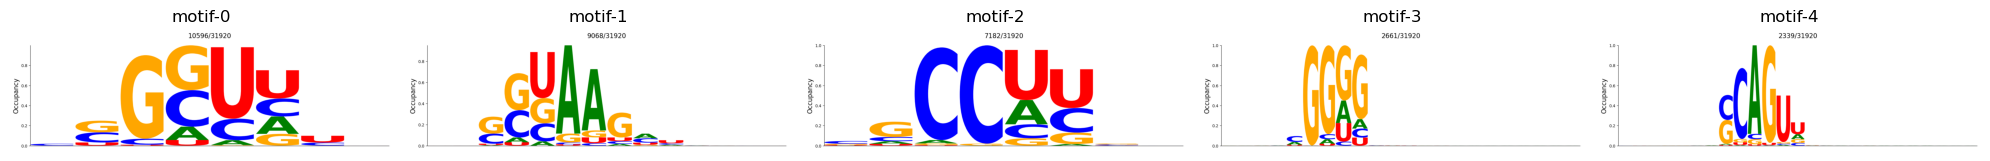

⏱ 0.79 s (00:00:00)


In [56]:
# ── Display consensus motif logos ──────────────────────────────────────────────
from PIL import Image

motif_pngs = sorted(_motifs_out_dir.glob("motif-*.png"))
fig, axes = plt.subplots(1, len(motif_pngs), figsize=(4 * len(motif_pngs), 3))
if len(motif_pngs) == 1:
    axes = [axes]
for ax, png in zip(axes, motif_pngs):
    ax.imshow(Image.open(png))
    ax.set_title(png.stem)
    ax.axis("off")
plt.tight_layout()
_run_label = EVAL_RUN.split(".globalclip")[0]  # e.g. "parnet.21m-0.0.unfreeze_last_2_layers"
plt.savefig(FILEPATHS["figures_dir"] / f"consensus_motifs.{_run_label}.png", dpi=150, bbox_inches="tight")
plt.show()

In [57]:
# ── Load consensus motif PPMs ──────────────────────────────────────────────────
def load_consensus_ppm(tsv_path):
    """Load a metamotif consensus motif TSV into a (L, 4) PPM array.
    Format: first line is '#support=N', then header 'A C G U', then rows.
    Columns are A, C, G, U (RNA) — we map U→T for matching against DNA PPMs.
    """
    df = pd.read_csv(tsv_path, sep="\t", comment="#")
    # columns are A, C, G, U → treat U as T
    mat = df[["A", "C", "G", "U"]].to_numpy(dtype=float)
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return mat / row_sums

consensus_motifs = {}
for tsv in sorted(_motifs_out_dir.glob("motif-*.tsv")):
    consensus_motifs[tsv.stem] = load_consensus_ppm(tsv)
    logger.info(f"{tsv.stem}: PPM shape {consensus_motifs[tsv.stem].shape}")

[15:54:09] INFO - motif-0: PPM shape (8, 4)
[15:54:09] INFO - motif-1: PPM shape (14, 4)
[15:54:09] INFO - motif-2: PPM shape (8, 4)
[15:54:09] INFO - motif-3: PPM shape (22, 4)
[15:54:09] INFO - motif-4: PPM shape (25, 4)


⏱ 0.02 s (00:00:00)


In [58]:
# ── Match consensus motifs against RBP database ────────────────────────────────
def best_pcc(query_ppm, target_ppm, min_overlap_frac=0.8):
    """Best sliding-window PCC between two PPMs of shape (L, 4).
    Requires overlap to be at least min_overlap_frac of the shorter motif,
    so a tiny window of a long motif can't score a lucky perfect match.
    """
    L1, L2 = len(query_ppm), len(target_ppm)
    required_overlap = int(np.ceil(min_overlap_frac * min(L1, L2)))
    best = -np.inf
    for shift in range(-(L2 - required_overlap), L1 - required_overlap + 1):
        s1 = max(0, shift)
        e1 = min(L1, shift + L2)
        s2 = s1 - shift
        e2 = s2 + (e1 - s1)
        if e1 - s1 < required_overlap:
            continue
        a = query_ppm[s1:e1].flatten()
        b = target_ppm[s2:e2].flatten()
        if a.std() == 0 or b.std() == 0:
            continue
        r, _ = pearsonr(a, b)
        if np.isfinite(r):
            best = max(best, r)
    return best if best > -np.inf else np.nan

# match each consensus motif against all RBPs
match_results = {}
for motif_name, query_ppm in consensus_motifs.items():
    rbp_best = {}
    for rbp, motif_list in all_motifs.items():
        best = max((best_pcc(query_ppm, m) for m in motif_list), default=np.nan)
        if np.isfinite(best):
            rbp_best[rbp] = best
    top_rbps = sorted(rbp_best.items(), key=lambda x: x[1], reverse=True)[:10]
    match_results[motif_name] = top_rbps

# print results
for motif_name, top_rbps in match_results.items():
    print(f"\n{motif_name} → top matching RBPs:")
    for rbp, score in top_rbps:
        print(f"   {rbp:15s}  PCC={score:.3f}")


motif-0 → top matching RBPs:
   PUF60            PCC=0.851
   SRSF5            PCC=0.847
   MSS116           PCC=0.836
   KHSRP            PCC=0.828
   RBM22            PCC=0.828
   XPO5             PCC=0.813
   FUBP1            PCC=0.800
   PTB3             PCC=0.780
   PTBP3            PCC=0.780
   MBNL1            PCC=0.779

motif-1 → top matching RBPs:
   SRP68            PCC=0.946
   F2               PCC=0.836
   RBMX             PCC=0.802
   SRSF9            PCC=0.779
   ZNF638           PCC=0.769
   HNRNPA1          PCC=0.767
   HNRNPDL          PCC=0.767
   DAZAP1           PCC=0.767
   HNRNPD           PCC=0.767
   HNRNPA2B1        PCC=0.767

motif-2 → top matching RBPs:
   RPO21            PCC=0.944
   MSS116           PCC=0.944
   SRSF5            PCC=0.921
   PCBP2            PCC=0.877
   PCBP1            PCC=0.832
   HEN1             PCC=0.814
   SRP19            PCC=0.807
   SRP68            PCC=0.807
   SRP54            PCC=0.807
   RBM23            PCC=0.792

motif-3 →

In [60]:
# ── Inspect information content per motif ──────────────────────────────────────
for name, ppm in consensus_motifs.items():
    ic = information_content(ppm)
    print(f"\n{name} (len {len(ppm)}):")
    print(f"  IC per position: {np.round(ic, 2)}")
    print(f"  min={ic.min():.2f}, max={ic.max():.2f}, mean={ic.mean():.2f}")


motif-0 (len 8):
  IC per position: [1.95 0.58 1.57 0.33 0.93 0.07 1.05 1.  ]
  min=0.07, max=1.95, mean=0.93

motif-1 (len 14):
  IC per position: [2.   0.42 0.7  0.51 0.33 1.34 0.99 0.82 0.23 0.47 0.45 0.   1.08 2.  ]
  min=0.00, max=2.00, mean=0.81

motif-2 (len 8):
  IC per position: [0.51 0.51 1.61 1.85 0.32 0.45 0.48 2.  ]
  min=0.32, max=2.00, mean=0.97

motif-3 (len 22):
  IC per position: [1.   1.   0.5  0.62 0.72 1.98 1.32 0.41 0.67 0.46 0.16 0.63 1.   1.
 2.   2.   2.   2.   2.   2.   2.   2.  ]
  min=0.16, max=2.00, mean=1.25

motif-4 (len 25):
  IC per position: [2.   2.   2.   2.   2.   0.5  0.78 0.78 1.46 1.31 1.79 1.51 0.25 0.04
 0.42 0.5  0.42 1.08 2.   2.   2.   2.   2.   2.   2.  ]
  min=0.04, max=2.00, mean=1.39
⏱ 0.00 s (00:00:00)


In [62]:
# ── Save motif → RBP matches ───────────────────────────────────────────────────
import json

match_out = {
    motif: [{"rbp": rbp, "pcc": round(float(score), 4)} for rbp, score in top_rbps]
    for motif, top_rbps in match_results.items()
}

_match_path = METAMOTIF_DIR / "rbp_matches.json"
_match_path.write_text(json.dumps(match_out, indent=2))
logger.info(f"Saved RBP matches → {_match_path}")

[15:58:39] INFO - Saved RBP matches → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/rbp_matches.json


⏱ 0.02 s (00:00:00)
